In [33]:
import pandas as pd
import numpy as np


try:
    df = pd.read_csv('titanic.csv')
except FileNotFoundError:
    print("titanic.csv not found. Attempting to load from a public URL.")
    df = pd.read_csv('https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv')

display(df.head())

titanic.csv not found. Attempting to load from a public URL.


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


In [34]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Survived                 887 non-null    int64  
 1   Pclass                   887 non-null    int64  
 2   Name                     887 non-null    object 
 3   Sex                      887 non-null    object 
 4   Age                      887 non-null    float64
 5   Siblings/Spouses Aboard  887 non-null    int64  
 6   Parents/Children Aboard  887 non-null    int64  
 7   Fare                     887 non-null    float64
dtypes: float64(2), int64(4), object(2)
memory usage: 55.6+ KB


None

In [35]:
# Display descriptive statistics for numerical columns
display(df.describe())

,Survived,Pclass,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
count,887.000000,887.000000,887.000000,887.000000,887.000000,887.00000
mean,0.385569,2.305524,29.471443,0.525366,0.383315,32.30542
std,0.487004,0.836662,14.121908,1.104669,0.807466,49.78204
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.00000
25%,0.000000,2.000000,20.250000,0.000000,0.000000,7.92500
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.45420
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.13750
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.32920


In [36]:
# Check for missing values
display(df.isnull().sum())

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
Siblings/Spouses Aboard,0
Parents/Children Aboard,0
Fare,0


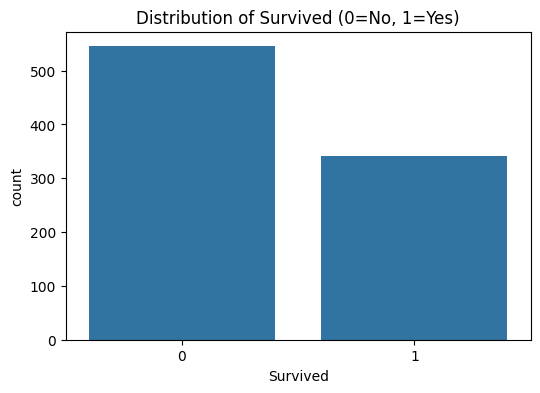

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df)
plt.title('Distribution of Survived (0=No, 1=Yes)')
plt.show()


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define target and features
y = df['Survived']
X = df.drop('Survived', axis=1)

# Identify categorical and numerical features
# Drop 'Name' and 'Ticket' as they are high cardinality and complex to process without further feature engineering
# 'Cabin' is dropped due to a high number of missing values and complexity of feature engineering

numerical_features = ['Age', 'Siblings/Spouses Aboard', 'Parents/Children Aboard', 'Fare']
categorical_features = ['Pclass', 'Sex'] # 'Embarked' column is not in the current dataset

# Preprocessing for numerical features: impute with median and scale
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical features: impute with most frequent and one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop' # Drop other columns not specified (like Name, Ticket, Cabin, PassengerId)
)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Data split into training and testing sets.
X_train shape: (709, 7)
X_test shape: (178, 7)


In [39]:
# Fit and transform the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Get the names of the one-hot encoded categorical features
onehot_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)

# Combine numerical and one-hot encoded feature names
all_feature_names = numerical_features + list(onehot_feature_names)

# Create a DataFrame from the processed training data for inspection
X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_feature_names)

display(X_train_processed_df.head())
print(f"Shape of processed training data: {X_train_processed.shape}")

,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male
0,-0.449010,-0.470388,-0.475009,-0.388597,0.0,1.0,0.0,0.0,1.0
1,-0.094153,1.275711,-0.475009,-0.484577,0.0,0.0,1.0,0.0,1.0
2,-1.939405,3.021810,1.992254,-0.042975,0.0,0.0,1.0,1.0,0.0
3,-0.094153,-0.470388,-0.475009,-0.388597,0.0,1.0,0.0,1.0,0.0
4,-0.803866,1.275711,1.992254,4.327664,1.0,0.0,0.0,1.0,0.0


Shape of processed training data: (709, 9)


In [40]:
from sklearn.linear_model import LogisticRegression

# Create the full pipeline by combining the preprocessor and a classifier
# We'll use Logistic Regression as a baseline model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

# Train the model
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [41]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
display(pd.DataFrame(conf_matrix, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

Model Accuracy: 0.7472

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.87      0.81       111
           1       0.72      0.54      0.62        67

    accuracy                           0.75       178
   macro avg       0.74      0.71      0.71       178
weighted avg       0.74      0.75      0.74       178


Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,97,14
Actual 1,31,36
